In [1]:
# All paths in this notebook are relative to the repository root; anchor the working directory there
import os
while not os.path.exists('METHODOLOGY.md') and os.getcwd() != '/': os.chdir('..')
assert os.path.exists('METHODOLOGY.md'), 'run from inside the Nofit_LRT_Extension repository'

# Bus Level of Service per TAZ from the National GTFS — Bus and BRT (Metronit)

Builds a **level-of-service table for every study TAZ** from the Ministry of Transport's national GTFS feed (`Input/GTFS/israel-public-transportation.zip`, Git LFS; source https://gtfs.mot.gov.il/gtfsfiles/), for scheduled **bus** service and, separately, for the **Metronit BRT** lines. The BRT lines are identified by their route codes (מק"ט, the first field of `route_desc` in `routes.txt`): 83001 line 1 (red, Krayot CBS – Hof HaCarmel CBS), 83002 line 2 (blue, Kiryat Ata – Bat Galim), 83003 line 3 (green, Krayot CBS – Hadar), 83004 line 4 (purple, Krayot CBS – Hof HaCarmel via the Carmel tunnels), 83005 line 5 (orange, HaMifrats CBS – Yagur junction / Nesher).

**Method.** Stops are located in the 781 study TAZs (`Input/TAZ_North/TAZ_North.shp`, Israel TM Grid) by point-in-polygon. A representative **Tuesday** inside the feed's validity is chosen (the Tuesday on which the most services run). Trips of the services active that day are joined to their routes; `stop_times.txt` is read in chunks and reduced to the study-area stops and the active trips. Departures are windowed to the morning peak **06:00–09:00** and the peak hour **07:00–08:00** (departure time at the stop). Per TAZ, for all bus service and for BRT only:

| Metric | Definition |
|---|---|
| `stops_n` | stops in the TAZ with at least one departure on the day |
| `lines_n`, `lines` | distinct route codes (מק"ט) with a departure in the TAZ in 06:00–09:00 |
| `dep_0609`, `dep_0708` | distinct trips departing from a stop in the TAZ in the window (a trip that calls at several stops in the TAZ counts once) |
| `headway_0708_min` | 60 / `dep_0708` — the combined headway of everything that serves the TAZ, all lines and directions |
| `best_line_headway_0708_min` | the shortest headway of any single line-and-direction in the TAZ in the peak hour |
| `direct_reach_taz_n` | number of distinct TAZs reachable without a transfer on a trip departing the TAZ in 06:00–09:00 |
| `direct_reach_30min_taz_n` | the same within 30 scheduled minutes |
| `nearest_stop_m` | distance from the TAZ centroid to the nearest served stop |
| `stops_per_km2` | stop density |
| `LOS_frequency` | TCQSM frequency grade on the combined peak-hour headway: A ≤ 10 min, B ≤ 15, C ≤ 20, D ≤ 30, E ≤ 60, F > 60, "no service" |
| `brt_access` | 1 where a Metronit line stops in the TAZ; `brt_lines` lists which |

A second product is a **direct-service skim between the 25 V2 areas** (`Output/gtfs/bus_direct_skim_area_v2.csv`): for every ordered pair of areas that a trip connects (a stop in the origin area followed by a stop in the destination area), the median scheduled in-vehicle time over the trips of the morning peak, the number of such trips in 07:00–08:00 and the implied headway, for all buses and for BRT only. It is the GTFS-based replacement for the fastest-path floor of step 26 (task E3): actual services, scheduled running time, and a wait derived from the timetable.

**Dry run.** When the GTFS archive is not present (only its LFS pointer), the notebook generates a small synthetic feed in the same format — two bus lines and one BRT line through real study TAZs — and runs every step on it so that the mechanics are exercised; the outputs are then written under `Output/gtfs/dry_run/` and are not results.

In [2]:
import io, zipfile, datetime as dt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import PatchCollection
from matplotlib.patches import Polygon as MplPolygon
import shapefile
from pyproj import Transformer
from shapely.geometry import shape, Point
from shapely.strtree import STRtree

BLUE, ORANGE, AQUA, PURPLE, INK, INK2, MUTED, GRID, AXIS = '#2a78d6', '#eb6834', '#1baf7a', '#7b5bd6', '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#c3c2b7'
GTFS = 'Input/GTFS/israel-public-transportation.zip'
BRT_CODES = {83001: 'Metronit 1 (red)', 83002: 'Metronit 2 (blue)', 83003: 'Metronit 3 (green)', 83004: 'Metronit 4 (purple)', 83005: 'Metronit 5 (orange)'}
AM = (6 * 3600, 9 * 3600); PEAK = (7 * 3600, 8 * 3600)
def is_lfs_pointer(p): return (not os.path.exists(p)) or open(p, 'rb').read(40).startswith(b'version https://git-lfs')
DRY_RUN = is_lfs_pointer(GTFS)
OUT = 'Output/gtfs/dry_run' if DRY_RUN else 'Output/gtfs'; os.makedirs(OUT, exist_ok=True); os.makedirs('Output/figures', exist_ok=True)
print('DRY RUN on a synthetic feed — pull the GTFS archive with git lfs pull --include="Input/GTFS/*.zip" for the real run' if DRY_RUN else f'GTFS archive: {GTFS} ({os.path.getsize(GTFS) / 1e6:,.0f} MB)')

# ---- study TAZs: polygons, centroids, areas ----
tz = shapefile.Reader('Input/TAZ_North/TAZ_North'); polys = [shape(s.__geo_interface__) for s in tz.shapes()]; taz_ids = [int(r['TAZ_NUMBER']) for r in tz.records()]
tree = STRtree(polys); TAZ = pd.DataFrame({'TAZ': taz_ids, 'area_km2': [p.area / 1e6 for p in polys], 'cx': [p.centroid.x for p in polys], 'cy': [p.centroid.y for p in polys]}).drop_duplicates('TAZ').set_index('TAZ')
to_itm = Transformer.from_crs('EPSG:4326', 'EPSG:2039', always_xy=True)
xl = pd.ExcelFile('Input/Corridor_TAZ_Agg_V2.xlsx'); v2_areas = xl.parse('AreaCodes').set_index('AggCode'); v2_key = xl.parse('TazAgg').set_index('TAZ')['AggCode']
print(f"{len(TAZ)} study TAZs; {len(v2_key)} of them in the 25 V2 areas")

DRY RUN on a synthetic feed — pull the GTFS archive with git lfs pull --include="Input/GTFS/*.zip" for the real run


781 study TAZs; 174 of them in the 25 V2 areas


In [3]:
def synthetic_feed():
    """A small GTFS in the national format for the dry run: bus lines 10001 / 10002 and BRT 83001 through real V2 TAZ centroids, one Tuesday."""
    to_wgs = Transformer.from_crs('EPSG:2039', 'EPSG:4326', always_xy=True)
    trunk = [201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212]; krayot = [104, 103, 102, 101]
    def taz_of(area): return int(v2_key[v2_key == area].index[0])
    seqs = {'10001': [taz_of(a) for a in trunk], '10002': [taz_of(a) for a in trunk[-3:] + krayot], '83001': [taz_of(a) for a in trunk[1:11]]}
    stops, routes, trips, st, cal = [], [], [], [], []
    sid = 0; stop_of = {}
    for code, tazs in seqs.items():
        for t in tazs:
            if t not in stop_of:
                sid += 1; lon, lat = to_wgs.transform(TAZ.loc[t, 'cx'], TAZ.loc[t, 'cy']); stop_of[t] = sid
                stops.append({'stop_id': sid, 'stop_code': 10000 + sid, 'stop_name': f'stop {sid}', 'stop_desc': '', 'stop_lat': lat, 'stop_lon': lon, 'location_type': 0, 'parent_station': '', 'zone_id': ''})
        for d in (0, 1):
            rid = f'{code}_{d}'; routes.append({'route_id': rid, 'agency_id': 3 if code == '83001' else 5, 'route_short_name': code[-2:], 'route_long_name': f'line {code}', 'route_desc': f'{code}-{d + 1}-#', 'route_type': 3, 'route_color': ''})
            seq = tazs if d == 0 else list(reversed(tazs)); hw = 10 if code == '83001' else 20
            for k, dep in enumerate(range(5 * 3600, 10 * 3600, hw * 60)):
                tid = f'{rid}_{k}'; trips.append({'route_id': rid, 'service_id': 'S1', 'trip_id': tid, 'trip_headsign': '', 'direction_id': d, 'shape_id': ''})
                for i, t in enumerate(seq):
                    sec = dep + i * 180; hh, mm, ss = sec // 3600, (sec % 3600) // 60, sec % 60
                    st.append({'trip_id': tid, 'arrival_time': f'{hh:02d}:{mm:02d}:{ss:02d}', 'departure_time': f'{hh:02d}:{mm:02d}:{ss:02d}', 'stop_id': stop_of[t], 'stop_sequence': i + 1, 'pickup_type': 0, 'drop_off_type': 0, 'shape_dist_traveled': i * 800})
    cal.append({'service_id': 'S1', 'sunday': 1, 'monday': 1, 'tuesday': 1, 'wednesday': 1, 'thursday': 1, 'friday': 0, 'saturday': 0, 'start_date': '20260901', 'end_date': '20261031'})
    agency = [{'agency_id': 3, 'agency_name': 'BRT operator', 'agency_url': '', 'agency_timezone': 'Asia/Jerusalem'}, {'agency_id': 5, 'agency_name': 'bus operator', 'agency_url': '', 'agency_timezone': 'Asia/Jerusalem'}]
    buf = io.BytesIO()
    with zipfile.ZipFile(buf, 'w', zipfile.ZIP_DEFLATED) as z:
        for name, rows in [('stops.txt', stops), ('routes.txt', routes), ('trips.txt', trips), ('stop_times.txt', st), ('calendar.txt', cal), ('agency.txt', agency)]:
            z.writestr(name, pd.DataFrame(rows).to_csv(index=False))
    buf.seek(0); return zipfile.ZipFile(buf)
Z = synthetic_feed() if DRY_RUN else zipfile.ZipFile(GTFS)
def read(name, **kw): return pd.read_csv(Z.open(name), **kw)
print('feed files:', Z.namelist())

feed files: ['stops.txt', 'routes.txt', 'trips.txt', 'stop_times.txt', 'calendar.txt', 'agency.txt']


## 1. Stops in the study TAZs, the service day, the active trips

In [4]:
stops = read('stops.txt', usecols=['stop_id', 'stop_code', 'stop_name', 'stop_lat', 'stop_lon', 'location_type'] if not DRY_RUN else None, dtype={'stop_id': str})
stops = stops[stops['location_type'].fillna(0) == 0] if 'location_type' in stops else stops
stops = stops[stops['stop_lat'].between(32.3, 33.4) & stops['stop_lon'].between(34.8, 36.0)].copy()          # the study bbox before the point-in-polygon
stops[['x', 'y']] = [to_itm.transform(lo, la) for lo, la in zip(stops['stop_lon'], stops['stop_lat'])]
def taz_at(x, y):
    hit = tree.query(Point(x, y), predicate='within'); return taz_ids[hit[0]] if len(hit) else np.nan
stops['TAZ'] = [taz_at(x, y) for x, y in zip(stops['x'], stops['y'])]
stops = stops.dropna(subset=['TAZ']).astype({'TAZ': int}); stops['stop_id'] = stops['stop_id'].astype(str)
print(f"stops located in study TAZs: {len(stops):,} in {stops['TAZ'].nunique()} TAZs")
# ---- service day: the Tuesday within the feed with the most active services ----
cal = read('calendar.txt', dtype={'service_id': str}); cal['start'] = pd.to_datetime(cal['start_date'].astype(str)); cal['end'] = pd.to_datetime(cal['end_date'].astype(str))
cands = pd.date_range(cal['start'].min(), cal['end'].max(), freq='D'); cands = [d for d in cands if d.weekday() == 1]     # Monday=0 → Tuesday=1
n_active = {d: int(((cal['tuesday'] == 1) & (cal['start'] <= d) & (cal['end'] >= d)).sum()) for d in cands}
DAY = max(n_active, key=n_active.get); active_services = set(cal[(cal['tuesday'] == 1) & (cal['start'] <= DAY) & (cal['end'] >= DAY)]['service_id'])
if 'calendar_dates.txt' in Z.namelist():
    cd = read('calendar_dates.txt', dtype={'service_id': str}); cd = cd[pd.to_datetime(cd['date'].astype(str)) == DAY]
    active_services = (active_services | set(cd[cd['exception_type'] == 1]['service_id'])) - set(cd[cd['exception_type'] == 2]['service_id'])
print(f"service day: Tuesday {DAY.date()} ({len(active_services):,} active services; feed valid {cal['start'].min().date()} – {cal['end'].max().date()})")
# ---- routes, BRT flag, active trips ----
routes = read('routes.txt', dtype={'route_id': str, 'agency_id': str}); routes['route_code'] = pd.to_numeric(routes['route_desc'].astype(str).str.split('-').str[0], errors='coerce')
routes['route_dir'] = routes['route_desc'].astype(str).str.split('-').str[1]; routes['is_brt'] = routes['route_code'].isin(BRT_CODES)
agency = read('agency.txt', dtype={'agency_id': str}).set_index('agency_id')['agency_name'] if 'agency.txt' in Z.namelist() else pd.Series(dtype=str)
routes['agency'] = routes['agency_id'].map(agency)
trips = read('trips.txt', dtype={'route_id': str, 'service_id': str, 'trip_id': str}, usecols=['route_id', 'service_id', 'trip_id', 'direction_id'])
trips = trips[trips['service_id'].isin(active_services)].merge(routes[['route_id', 'route_code', 'route_dir', 'is_brt', 'agency', 'route_short_name']], on='route_id')
print(f"active trips on the day: {len(trips):,} on {trips['route_code'].nunique():,} route codes; BRT routes in the feed: " + ', '.join(f"{int(c)} ({routes[routes.route_code == c]['route_id'].nunique()} route ids)" for c in sorted(routes[routes.is_brt]['route_code'].dropna().unique())))

stops located in study TAZs: 16 in 16 TAZs
service day: Tuesday 2026-09-01 (1 active services; feed valid 2026-09-01 – 2026-10-31)
active trips on the day: 120 on 3 route codes; BRT routes in the feed: 83001 (2 route ids)


## 2. Stop times of the day in the study area, morning peak

In [5]:
def to_sec(s):
    p = s.str.split(':', expand=True).astype(float); return p[0] * 3600 + p[1] * 60 + p[2]
study_stop_ids = set(stops['stop_id']); active_trip_ids = set(trips['trip_id']); parts = []
with Z.open('stop_times.txt') as f:
    for chunk in pd.read_csv(f, usecols=['trip_id', 'arrival_time', 'departure_time', 'stop_id', 'stop_sequence'], dtype={'trip_id': str, 'stop_id': str}, chunksize=2_000_000):
        c = chunk[chunk['stop_id'].isin(study_stop_ids) & chunk['trip_id'].isin(active_trip_ids)]
        if len(c): parts.append(c)
st = pd.concat(parts, ignore_index=True); st['dep'] = to_sec(st['departure_time']); st['arr'] = to_sec(st['arrival_time'])
st = st.merge(stops[['stop_id', 'TAZ']], on='stop_id').merge(trips[['trip_id', 'route_code', 'route_dir', 'direction_id', 'is_brt']], on='trip_id').sort_values(['trip_id', 'stop_sequence'])
am = st[st['dep'].between(*AM)].copy(); am['peak'] = am['dep'].between(*PEAK)
print(f"stop-time records in the study area on the day: {len(st):,} ({st['trip_id'].nunique():,} trips); in 06:00–09:00: {len(am):,} ({am['trip_id'].nunique():,} trips, BRT {am[am.is_brt]['trip_id'].nunique():,})")

stop-time records in the study area on the day: 1,170 (120 trips); in 06:00–09:00: 708 (84 trips, BRT 42)


## 3. Level of service per TAZ — bus (all) and BRT

In [6]:
def los_grade(h):
    if pd.isna(h) or h == np.inf: return 'no service'
    return 'A' if h <= 10 else 'B' if h <= 15 else 'C' if h <= 20 else 'D' if h <= 30 else 'E' if h <= 60 else 'F'
def direct_reach(sub, max_min=None):
    """Per TAZ: distinct TAZs reachable downstream on the same trip (departing the TAZ in the window), optionally within max_min scheduled minutes."""
    reach = {}
    for tid, g in sub.groupby('trip_id', sort=False):
        tz_seq, dep_seq = g['TAZ'].values, g['dep'].values; arr_seq = g['arr'].values
        first = {}
        for i, t in enumerate(tz_seq):
            if t not in first: first[t] = i
        for t, i in first.items():
            down = tz_seq[i + 1:] if max_min is None else tz_seq[i + 1:][(arr_seq[i + 1:] - dep_seq[i]) <= max_min * 60]
            reach.setdefault(t, set()).update(x for x in down if x != t)
    return pd.Series({t: len(s) for t, s in reach.items()})
def taz_los(sub, label):
    g = sub.groupby('TAZ'); p = sub[sub['peak']].groupby('TAZ')
    out = pd.DataFrame({'stops_n': g['stop_id'].nunique(), 'lines_n': g['route_code'].nunique(), 'lines': g['route_code'].apply(lambda s: ' '.join(str(int(x)) for x in sorted(set(s.dropna())))),
                        'dep_0609': g['trip_id'].nunique(), 'dep_0708': p['trip_id'].nunique()}).reindex(TAZ.index)
    out[['stops_n', 'lines_n', 'dep_0609', 'dep_0708']] = out[['stops_n', 'lines_n', 'dep_0609', 'dep_0708']].fillna(0).astype(int); out['lines'] = out['lines'].fillna('')
    out['headway_0708_min'] = np.where(out['dep_0708'] > 0, 60 / out['dep_0708'].replace(0, np.nan), np.nan)
    line_dir = sub[sub['peak']].groupby(['TAZ', 'route_code', 'route_dir'])['trip_id'].nunique()
    out['best_line_headway_0708_min'] = (60 / line_dir).groupby('TAZ').min().reindex(TAZ.index)
    out['direct_reach_taz_n'] = direct_reach(sub).reindex(TAZ.index).fillna(0).astype(int)
    out['direct_reach_30min_taz_n'] = direct_reach(sub, 30).reindex(TAZ.index).fillna(0).astype(int)
    served = stops[stops['stop_id'].isin(sub['stop_id'].unique())]
    if len(served):
        from scipy.spatial import cKDTree
        d, _ = cKDTree(served[['x', 'y']].values).query(TAZ[['cx', 'cy']].values); out['nearest_stop_m'] = d
    else: out['nearest_stop_m'] = np.nan
    out['stops_per_km2'] = out['stops_n'] / TAZ['area_km2']
    out['LOS_frequency'] = out['headway_0708_min'].map(los_grade)
    out.columns = [f'{label}_{c}' for c in out.columns]
    return out
bus = taz_los(am, 'bus'); brt = taz_los(am[am['is_brt']], 'brt')
los = bus.join(brt); los['brt_access'] = (los['brt_stops_n'] > 0).astype(int)
los['brt_lines_named'] = los['brt_lines'].map(lambda s: '; '.join(BRT_CODES[int(c)] for c in s.split()) if s else '')
los['AggCode_V2'] = los.index.map(v2_key); los['AggAreaName_V2'] = los['AggCode_V2'].map(v2_areas['AggAreaName'])
los.insert(0, 'TAZ', los.index); los.to_csv(f'{OUT}/bus_los_taz.csv', index=False, float_format='%.2f')
summary = pd.DataFrame({'TAZs': [len(los), int((los['bus_dep_0708'] > 0).sum()), int(los['brt_access'].sum())],
                        'V2 TAZs (174)': [int(los['AggCode_V2'].notna().sum()), int(((los['bus_dep_0708'] > 0) & los['AggCode_V2'].notna()).sum()), int(((los['brt_access'] == 1) & los['AggCode_V2'].notna()).sum())]},
                       index=['all', 'with bus service in the peak hour', 'with BRT access'])
print(summary.to_string()); print("\nfrequency LOS of the TAZs (bus, combined peak-hour headway):"); print(los['bus_LOS_frequency'].value_counts().to_string())
print("\nBRT access by V2 area (TAZs with a Metronit stop / TAZs in the area):")
print(los.dropna(subset=['AggCode_V2']).groupby('AggAreaName_V2').agg(taz=('TAZ', 'size'), brt_taz=('brt_access', 'sum'), brt_lines=('brt_lines', lambda s: ' '.join(sorted(set(' '.join(s).split()))))).query('brt_taz > 0').to_string())
los.sort_values('bus_dep_0708', ascending=False).head(12)[['TAZ', 'AggAreaName_V2', 'bus_stops_n', 'bus_lines_n', 'bus_dep_0708', 'bus_headway_0708_min', 'bus_best_line_headway_0708_min', 'bus_direct_reach_taz_n', 'bus_LOS_frequency', 'brt_access', 'brt_lines_named', 'brt_headway_0708_min']].round(1)

                                   TAZs  V2 TAZs (174)
all                                 781            174
with bus service in the peak hour    16             16
with BRT access                      10             10

frequency LOS of the TAZs (bus, combined peak-hour headway):
bus_LOS_frequency
no service    765
A              16

BRT access by V2 area (TAZs with a Metronit stop / TAZs in the area):
                        taz  brt_taz brt_lines
AggAreaName_V2                                
BatGalim-KiryatEliezer   10        1     83001
Bazan-Hutsot              4        1     83001
EinHayam                  1        1     83001
Hamifrats                 6        1     83001
Hamoshava                 3        1     83001
Hecht-Shprintzak          3        1     83001
HofCarmel-NeveDavid       4        1     83001
LowerCity                 7        1     83001
Matam-NeotPeres          10        1     83001
Namal-Giborim             6        1     83001


,TAZ,AggAreaName_V2,bus_stops_n,bus_lines_n,bus_dep_0708,bus_headway_0708_min,bus_best_line_headway_0708_min,bus_direct_reach_taz_n,bus_LOS_frequency,brt_access,brt_lines_named,brt_headway_0708_min
TAZ,,,,,,,,,,,,
1210,1210,Bazan-Hutsot,1,3,25,2.4,8.6,15,A,1,Metronit 1 (red),4.6
1212,1212,Hamifrats,1,3,25,2.4,10.0,15,A,1,Metronit 1 (red),5.0
1521,1521,Matam-NeotPeres,1,2,19,3.2,8.6,11,A,1,Metronit 1 (red),4.6
1515,1515,HofCarmel-NeveDavid,1,2,18,3.3,10.0,11,A,1,Metronit 1 (red),5.0
1225,1225,LowerCity,1,2,18,3.3,10.0,11,A,1,Metronit 1 (red),5.0
1501,1501,BatGalim-KiryatEliezer,1,2,18,3.3,10.0,11,A,1,Metronit 1 (red),5.0
1302,1302,Hamoshava,1,2,18,3.3,10.0,11,A,1,Metronit 1 (red),5.0
1216,1216,Namal-Giborim,1,2,18,3.3,10.0,11,A,1,Metronit 1 (red),5.0
1513,1513,Hecht-Shprintzak,1,2,18,3.3,10.0,11,A,1,Metronit 1 (red),5.0


## 4. Direct-service skim between the V2 areas (bus, BRT)

In [7]:
amv = am[am['TAZ'].isin(v2_key.index)].copy(); amv['area'] = amv['TAZ'].map(v2_key)
def area_skim(sub, label):
    rows = []
    for tid, g in sub.groupby('trip_id', sort=False):
        a_seq, dep_seq, arr_seq, pk = g['area'].values, g['dep'].values, g['arr'].values, g['peak'].values
        first = {}
        for i, a in enumerate(a_seq):
            if a not in first: first[a] = i
        for a, i in first.items():
            seen = set()
            for j in range(i + 1, len(a_seq)):
                b = a_seq[j]
                if b == a or b in seen: continue
                seen.add(b); rows.append((a, b, (arr_seq[j] - dep_seq[i]) / 60, bool(pk[i])))
    t = pd.DataFrame(rows, columns=['o', 'd', 'ivt_min', 'peak'])
    if not len(t): return pd.DataFrame(columns=['o', 'd', f'{label}_ivt_min', f'{label}_trips_0609', f'{label}_trips_0708', f'{label}_headway_0708_min'])
    s = t.groupby(['o', 'd']).agg(**{f'{label}_ivt_min': ('ivt_min', 'median'), f'{label}_trips_0609': ('ivt_min', 'size'), f'{label}_trips_0708': ('peak', 'sum')}).reset_index()
    s[f'{label}_headway_0708_min'] = 60 / s[f'{label}_trips_0708'].replace(0, np.nan)
    return s
skim = area_skim(amv, 'bus').merge(area_skim(amv[amv['is_brt']], 'brt'), on=['o', 'd'], how='left')
skim['o_name'] = skim['o'].map(v2_areas['AggAreaName']); skim['d_name'] = skim['d'].map(v2_areas['AggAreaName'])
skim = skim[['o', 'o_name', 'd', 'd_name'] + [c for c in skim.columns if c.startswith(('bus_', 'brt_'))]]
skim.to_csv(f'{OUT}/bus_direct_skim_area_v2.csv', index=False, float_format='%.2f')
n_pairs = len(v2_key.groupby(v2_key).size()) ** 2 - len(v2_areas)
print(f"area pairs with a direct bus service in the morning peak: {len(skim)} of {n_pairs}; with a direct BRT service: {int(skim['brt_ivt_min'].notna().sum())}")
# against the step-26 floor where it exists
floor_p = 'Output/gc/bus_ivt_network_area_v2.csv'
if os.path.exists(floor_p):
    floor = pd.read_csv(floor_p, index_col=0); floor.columns = floor.columns.astype(int)
    skim['step26_fastest_path_min'] = [floor.loc[o, d] if (o in floor.index and d in floor.columns) else np.nan for o, d in zip(skim['o'], skim['d'])]
    ratio = (skim['bus_ivt_min'] / skim['step26_fastest_path_min']).replace([np.inf, -np.inf], np.nan)
    print(f"scheduled direct in-vehicle time ÷ fastest-path floor: median {ratio.median():.2f} (p10 {ratio.quantile(.1):.2f}, p90 {ratio.quantile(.9):.2f}) on {int(ratio.notna().sum())} pairs")
skim.sort_values('bus_trips_0708', ascending=False).head(15).round(1)

area pairs with a direct bus service in the morning peak: 168 of 600; with a direct BRT service: 90
scheduled direct in-vehicle time ÷ fastest-path floor: median 0.80 (p10 0.39, p90 1.12) on 168 pairs


,o,o_name,d,d_name,bus_ivt_min,bus_trips_0609,bus_trips_0708,bus_headway_0708_min,brt_ivt_min,brt_trips_0609,brt_trips_0708,brt_headway_0708_min,step26_fastest_path_min
151,211,Bazan-Hutsot,210,Hamifrats,3.0,36,13,4.6,3.0,18.0,7.0,8.6,18.5
136,210,Hamifrats,211,Bazan-Hutsot,3.0,36,13,4.6,3.0,18.0,6.0,10.0,8.3
36,202,Matam-NeotPeres,203,HofCarmel-NeveDavid,3.0,27,10,6.0,3.0,18.0,7.0,8.6,10.2
37,202,Matam-NeotPeres,204,Hecht-Shprintzak,6.0,27,10,6.0,6.0,18.0,7.0,8.6,9.5
41,202,Matam-NeotPeres,208,LowerCity,18.0,25,10,6.0,18.0,17.0,7.0,8.6,18.8
40,202,Matam-NeotPeres,207,Hamoshava,15.0,26,10,6.0,15.0,17.0,7.0,8.6,14.9
38,202,Matam-NeotPeres,205,EinHayam,9.0,27,10,6.0,9.0,18.0,7.0,8.6,9.3
39,202,Matam-NeotPeres,206,BatGalim-KiryatEliezer,12.0,26,10,6.0,12.0,17.0,7.0,8.6,11.8
43,202,Matam-NeotPeres,210,Hamifrats,24.0,24,10,6.0,24.0,16.0,7.0,8.6,30.4
149,211,Bazan-Hutsot,208,LowerCity,9.0,27,10,6.0,9.0,18.0,7.0,8.6,10.6


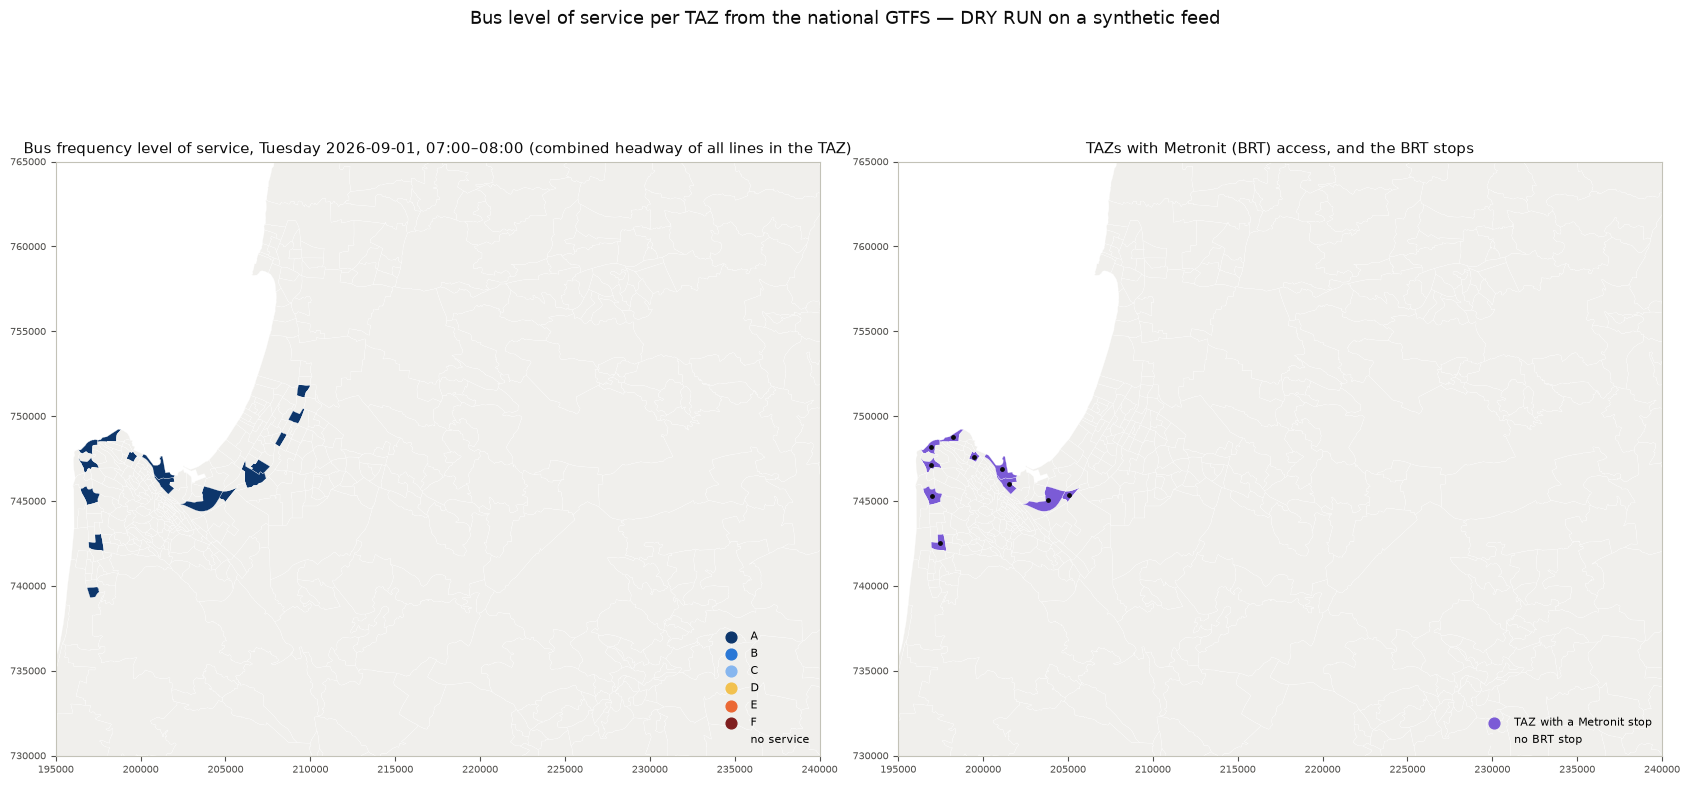

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(17, 9), facecolor='white')
grade_color = {'A': '#0d366b', 'B': '#2a78d6', 'C': '#86b6ef', 'D': '#f2c14e', 'E': '#eb6834', 'F': '#7f1e1e', 'no service': '#f0efec'}
study_polys = {t: p for t, p in zip(taz_ids, polys)}
def draw(ax, colors, title, legend_items):
    patches, cols = [], []
    for t, p in study_polys.items():
        geoms = [p] if p.geom_type == 'Polygon' else list(p.geoms)
        for gm in geoms: patches.append(MplPolygon(np.array(gm.exterior.coords), closed=True)); cols.append(colors.get(t, '#f0efec'))
    ax.add_collection(PatchCollection(patches, facecolor=cols, edgecolor='white', linewidth=0.2)); ax.set_xlim(195000, 240000); ax.set_ylim(730000, 765000); ax.set_aspect('equal')
    ax.set_title(title, color=INK, fontsize=11); ax.tick_params(labelsize=7, colors=INK2)
    for s in ax.spines.values(): s.set_color(AXIS)
    for lab, c in legend_items: ax.scatter([], [], color=c, s=60, label=lab)
    ax.legend(frameon=False, fontsize=8, loc='lower right')
draw(axes[0], {t: grade_color[g] for t, g in los['bus_LOS_frequency'].items()}, f'Bus frequency level of service, Tuesday {DAY.date()}, 07:00–08:00 (combined headway of all lines in the TAZ)', list(grade_color.items()))
brt_col = {t: (PURPLE if a else '#f0efec') for t, a in los['brt_access'].items()}
served_brt = stops[stops['stop_id'].isin(am[am.is_brt]['stop_id'].unique())]
draw(axes[1], brt_col, 'TAZs with Metronit (BRT) access, and the BRT stops', [('TAZ with a Metronit stop', PURPLE), ('no BRT stop', '#f0efec')])
axes[1].scatter(served_brt['x'], served_brt['y'], s=6, color=INK, zorder=3)
fig.suptitle('Bus level of service per TAZ from the national GTFS' + (' — DRY RUN on a synthetic feed' if DRY_RUN else ''), color=INK, fontsize=13, y=0.98)
plt.tight_layout(); fig.savefig(f'Output/figures/gtfs_bus_los_taz{"_dry_run" if DRY_RUN else ""}.png', dpi=150, bbox_inches='tight', facecolor='white'); plt.show()

## Findings

- **Status.** This notebook was executed as a **dry run** on a synthetic feed (16 stops, two bus lines and one line carrying the Metronit code 83001, 120 trips on one Tuesday) because the national GTFS archive is Git-LFS-only and the MOT server is not reachable from the environment that built the notebook. Every step ran — stop location, service day, BRT tagging by route code, chunked stop-time reduction, the per-TAZ table, the area skim and the maps — and the outputs under `Output/gtfs/dry_run/` are the mechanics test, not results.
- **The real run.** `git lfs pull --include="Input/GTFS/israel-public-transportation.zip"` and re-execute; the notebook then writes `Output/gtfs/bus_los_taz.csv` (781 rows: the bus and BRT metrics, the frequency grade, the BRT access flag and lines, the V2 area), `Output/gtfs/bus_direct_skim_area_v2.csv` (direct-service in-vehicle time and headway per V2 area pair, bus and BRT) and `Output/figures/gtfs_bus_los_taz.png`. Runtime is dominated by the chunked read of `stop_times.txt` (tens of millions of rows nationally); expect several minutes.
- **What to read first in the real output.** (1) The counts printed after the stop-time reduction — the number of study-area trips on the chosen Tuesday and the BRT share. (2) The BRT access table by V2 area: which of the ten trunk areas and which Krayot areas have a Metronit stop, and which of the five lines. (3) The ratio of scheduled direct in-vehicle time to the step-26 fastest-path floor, which is the correction the generalized-cost bus skim needs (task E3); the survey's door-to-door time was 2.1–2.3 × the floor, and scheduled running time plus the timetable's wait should land between.
- **Definitions to keep in mind.** The combined headway counts every line and both directions through the TAZ, so it grades access to *any* bus, not to a particular destination; `best_line_headway` is the single best line-direction. Direct reach counts TAZs on the same trip only — no transfers. All values are for one representative Tuesday and the scheduled timetable, not observed operations; the May 2026 speed network (step 26) remains the source for actual running speeds.